In [1]:
import sys
sys.path.append("../")

import healpy as hp

from models.bulge_models import BulgeTemplates
from models.templates import LorimerDiskTemplate, NFWTemplate

%load_ext autoreload
%autoreload 2

## Loading NFW template

Docstring:
```py
"""Generate HEALPix map of NFW template

Args:
    nside (int, optional): HEALPix nside of map. Defaults to 128.
    outer (float, optional): Maximum outer radius (smaller = generation). Defaults to 300
    n_integ (int, optional): Number of integration steps in line-of-sight integral. Defaults to 500.
    rsun (float, optional): Solar radius. Defaults to 8.224.
    r_s (float, optional): Scale radius of NFW profile. Defaults to 20.0.
    r_norm (float, optional): Normalization ROI. Defaults to 30.0.
"""
```

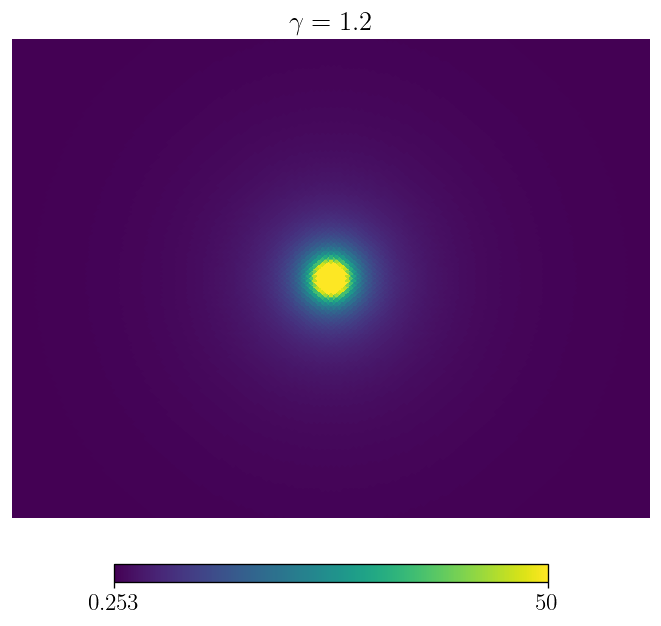

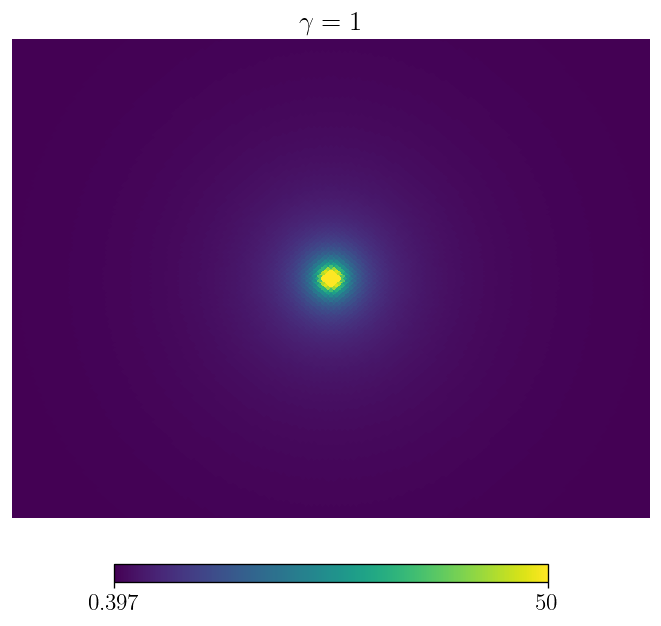

In [7]:
nfw_template = NFWTemplate(nside=256, rsun=8.224, r_s=20.0, n_integ=4000)

# Generate maps with different gamma

temp_gce = nfw_template.get_NFW2_template(gamma=1.2)
hp.cartview(temp_gce, lonra=[-20,20], latra=[-15,15], max=50, title="$\gamma=1.2$")

temp_gce = nfw_template.get_NFW2_template(gamma=1.)
hp.cartview(temp_gce, lonra=[-20,20], latra=[-15,15], max=50, title="$\gamma=1$")

## Loading Lorimer disk templates

The disk is parameterized according to Eq. (6) of Bartels et al ([1805.11097](https://arxiv.org/abs/1805.11097)):
$$
n(r, z)= N \frac{C^{B+2}}{4 \pi R_{\odot}^2 z_s e^C \Gamma(B+2)} \times 
\left(\frac{r}{R_{\odot}}\right)^B \exp \left[-C\left(\frac{r-R_{\odot}}{R_{\odot}}\right)\right] \times 
\exp \left(-\frac{|z|}{z_s}\right) .
$$

Docstring:
```py
"""Lorimer disk spatial template in HEALPix projection

Args:
    nside (int, optional): HEALPix nside. Defaults to 128.
    outer (float, optional): Maximum outer radius to use. Smaller = faster generation. Defaults to 40.
    n_integ (int, optional): Number of steps in line of sight integral. Defaults to 2000.
    rsun (float, optional): Solar radius. Defaults to 8.224.
    r_norm (float, optional): Radius to normalize template to. Defaults to 30.0.
"""
```

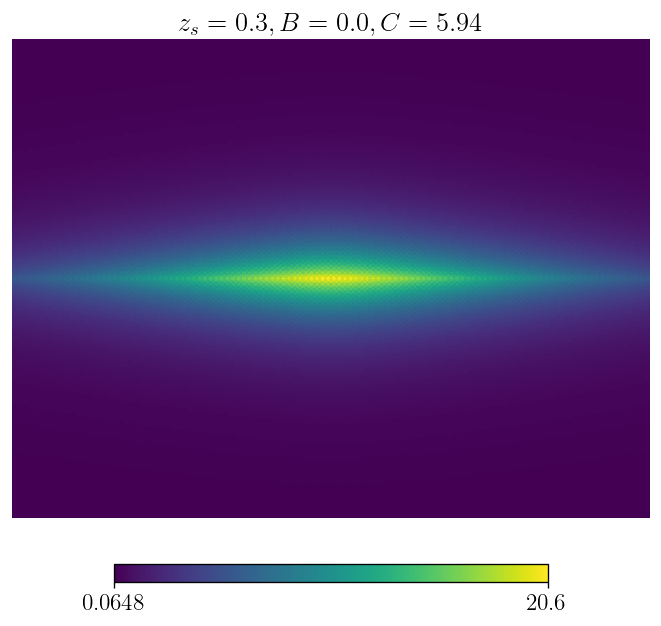

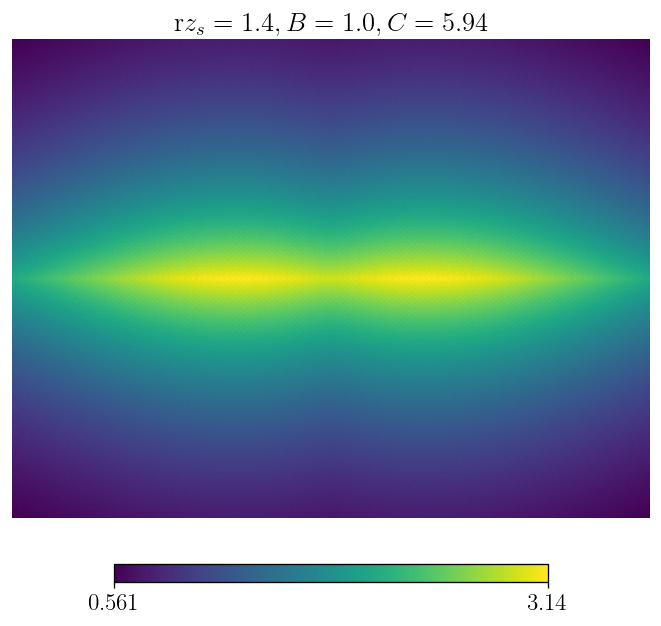

In [8]:
disk_template = LorimerDiskTemplate(nside=256, rsun=8.224, n_integ=4000)

temp_dsk = disk_template.get_template(zs=0.3, B=0.0, C=5.94)
hp.cartview(temp_dsk, lonra=[-20,20], latra=[-15,15], title=r"$z_s=0.3, B=0.0, C=5.94$")

temp_dsk = disk_template.get_template(zs=1.4, B=1.0, C=5.94)
hp.cartview(temp_dsk, lonra=[-20,20], latra=[-15,15], title="r$z_s=1.4, B=1.0, C=5.94$")

## Loading bulge templates

Load bulge templates from the literature. Docstring:
```py
"""Load bulge templates from the literature, The "mcdermott*" templates are from McDermott et al. 2022 (https://arxiv.org/abs/2209.00006), downloaded from https://github.com/samueldmcdermott/gcepy/tree/main/gcepy/inputs/excesses. The other templates are downloaded from https://github.com/chrisgordon1/galactic_bulge_templates.

Args:
    template_name (str, optional): Identifying string. Defaults to "macias2019".
    nside_project (int, optional): HEALPix nside to project cartesian input maps to. Defaults to 512.
    nside_out (int, optional): HEALPix nside to downgrade output maps to. Defaults to 128.
    r_norm (float, optional): Normalization ROI. Defaults to 30.0.
"""
```

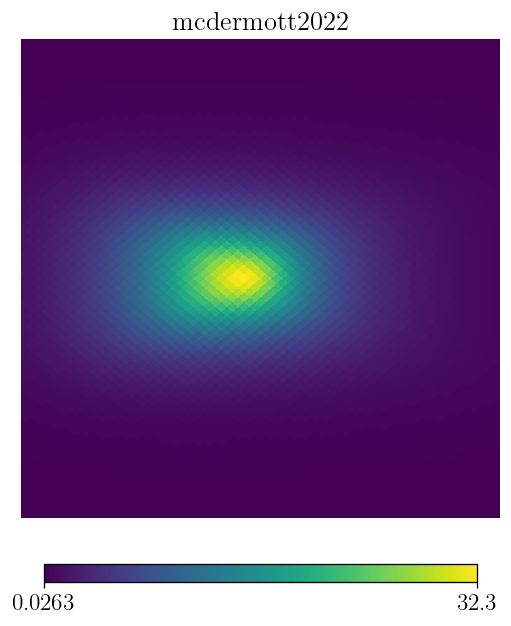

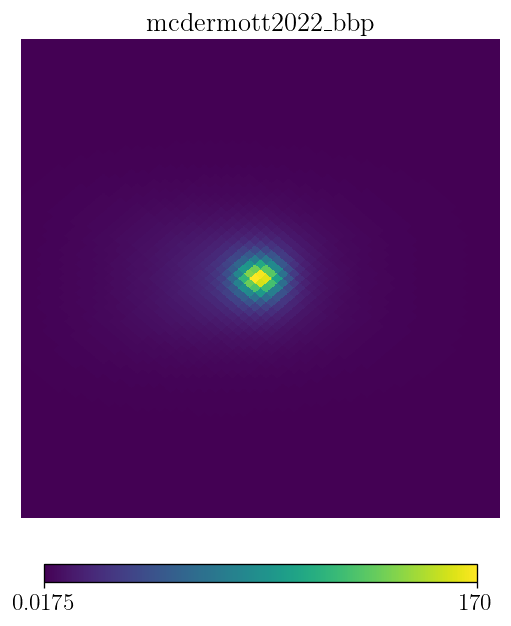

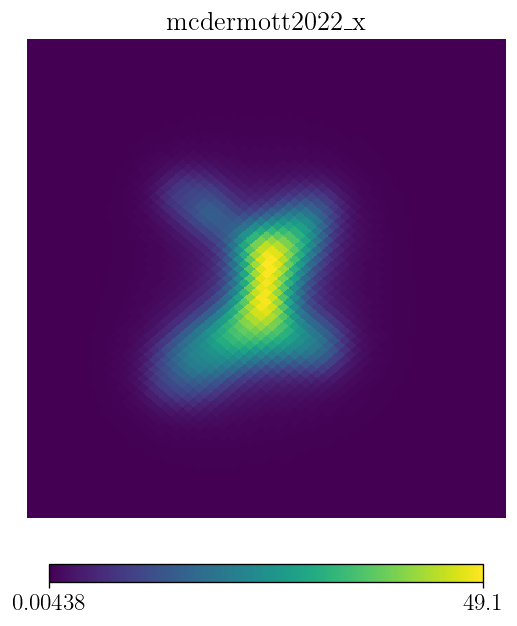

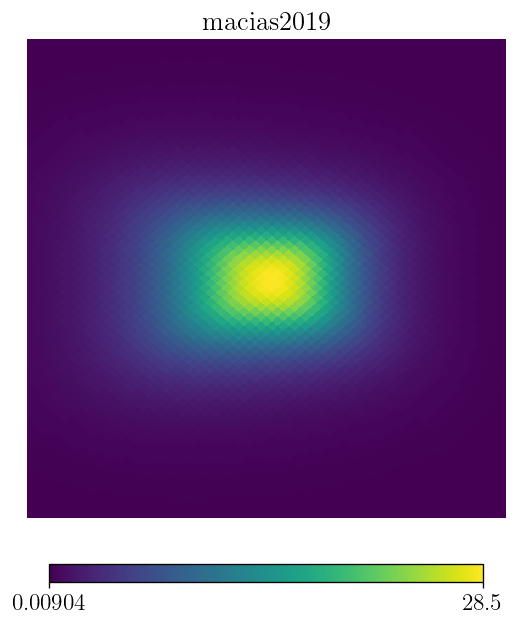

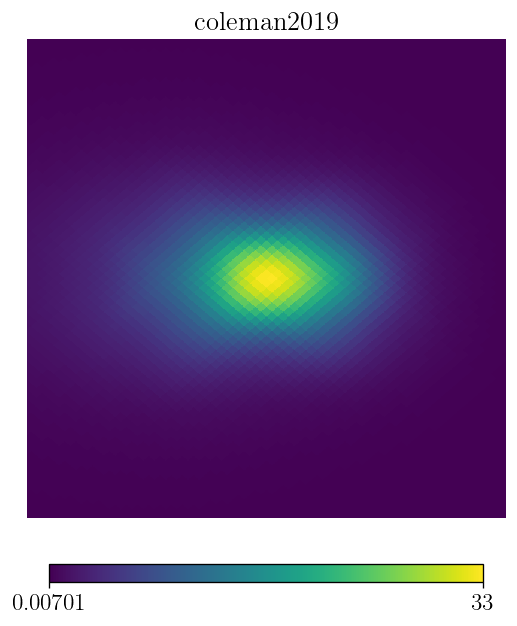

In [10]:
template_names=["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"]
for template_name in template_names:
    temp_blg = BulgeTemplates(template_name=template_name,)()
    hp.cartview(temp_blg, latra=[-15,15], lonra=[-15,15], title=template_name);